## PHARMDEKO STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

pharmdeko=pd.read_csv('../stock_data/pharmdeko.csv') ## so it can be small letter. This is cool.
pharmdeko=pharmdeko.drop(columns=['high_price','low_price'])
pharmdeko.rename(columns={'trade_date':'date'},inplace=True)
pharmdeko['date']=pd.to_datetime(pharmdeko['date'])
pharmdeko['month']=pharmdeko['date'].dt.month
pharmdeko['quarter']=pharmdeko['date'].dt.quarter
pharmdeko['year']=pharmdeko['date'].dt.year

pharmdeko

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42835,PHARMDEKO,2017-01-03,1.78,1.78,0.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43395,PHARMDEKO,2017-01-04,1.78,1.78,200000.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43505,PHARMDEKO,2017-01-05,1.78,1.78,700.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43615,PHARMDEKO,2017-01-06,1.78,1.78,51545.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43705,PHARMDEKO,2017-01-09,1.78,1.78,0.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298116,PHARMDEKO,2026-07-13,1.83,1.83,NaN,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298554,PHARMDEKO,2026-07-14,1.83,1.83,NaN,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298992,PHARMDEKO,2026-07-15,1.83,1.83,NaN,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299430,PHARMDEKO,2026-07-16,1.83,1.83,NaN,2026-07-16T15:10:03.113936+00:00,7,3,2026


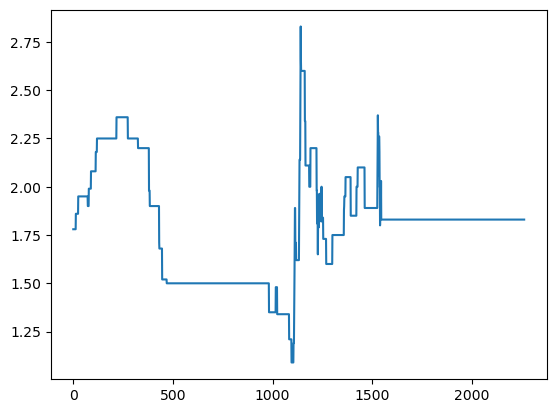

In [2]:
import matplotlib.pyplot as plt

plt.plot(pharmdeko['close_price'])
plt.show()

In [3]:
pharmdeko_end_month_df = (
    pharmdeko
    .sort_values("date")
    .groupby(pharmdeko["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

pharmdeko_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45405,PHARMDEKO,2017-01-31,1.86,1.86,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47227,PHARMDEKO,2017-02-28,1.95,1.95,520.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49343,PHARMDEKO,2017-03-31,1.95,1.95,1500.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51170,PHARMDEKO,2017-04-28,1.99,1.99,250.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53093,PHARMDEKO,2017-05-31,2.08,2.08,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35353,PHARMDEKO,2026-03-31,1.83,1.83,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281179,PHARMDEKO,2026-04-30,1.83,1.83,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284245,PHARMDEKO,2026-05-29,1.83,1.83,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294173,PHARMDEKO,2026-06-30,1.83,1.83,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026


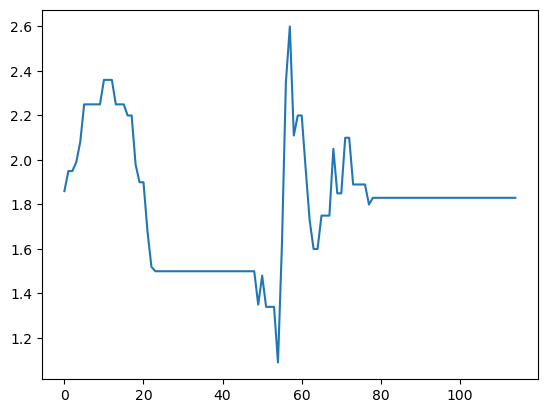

In [4]:
plt.plot(pharmdeko_end_month_df['close_price'])
plt.show()

In [5]:
pharmdeko_end_month_df['returns']=pharmdeko_end_month_df['close_price'].pct_change()*100
pharmdeko_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45405,PHARMDEKO,2017-01-31,1.86,1.86,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47227,PHARMDEKO,2017-02-28,1.95,1.95,520.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,4.838710
2,49343,PHARMDEKO,2017-03-31,1.95,1.95,1500.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51170,PHARMDEKO,2017-04-28,1.99,1.99,250.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,2.051282
4,53093,PHARMDEKO,2017-05-31,2.08,2.08,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,4.522613
...,...,...,...,...,...,...,...,...,...,...,...
110,35353,PHARMDEKO,2026-03-31,1.83,1.83,0.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281179,PHARMDEKO,2026-04-30,1.83,1.83,NaN,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
112,284245,PHARMDEKO,2026-05-29,1.83,1.83,NaN,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294173,PHARMDEKO,2026-06-30,1.83,1.83,NaN,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


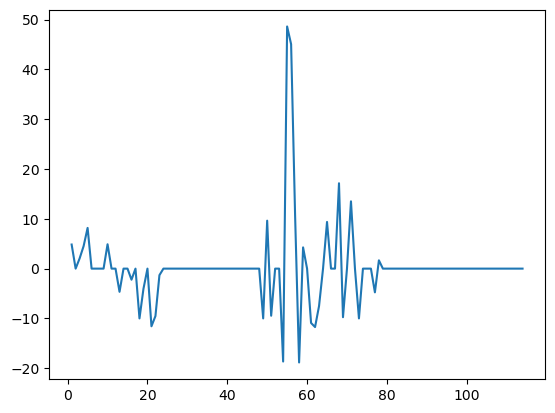

In [6]:
plt.plot(pharmdeko_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(pharmdeko_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-8.268319122786087, 4.869797882837609e-13, 1, 112, {'1%': -3.4901313156261384, '5%': -2.8877122815688776, '10%': -2.5807296460459184}, 703.4951225798086)
stationary


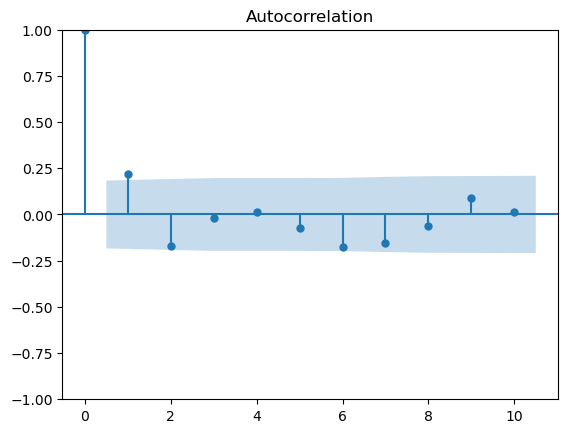

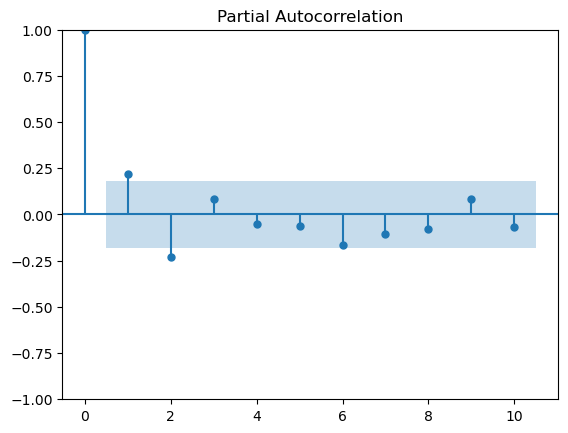

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(pharmdeko_end_month_df['returns'].dropna(), lags=10)
plot_pacf(pharmdeko_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=pharmdeko_end_month_df['close_price'][:-10]
test=pharmdeko_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -1.6980940380417272e+31]
[0, 0, 0, 0, 0, 1, -7.253623128597293e+30]
[0, 0, 0, 0, 0, 2, -9.44892084428889e+29]
[0, 0, 0, 0, 1, 0, 1.0]
[0, 0, 0, 0, 1, 1, -1.7698808836926927e+28]
[0, 0, 0, 0, 1, 2, -8.535171490068408e+27]
[0, 0, 0, 0, 2, 0, -4604646057.6]
[0, 0, 0, 0, 2, 1, -1.1365139219154335e+28]
[0, 0, 0, 0, 2, 2, -1.154458276552652e+28]
[0, 0, 0, 1, 0, 0, -5.043520958120443e+27]
[0, 0, 0, 1, 0, 1, -2.0017040219167567e+28]
[0, 0, 0, 1, 0, 2, -1.0292435379030678e+28]
[0, 0, 0, 1, 1, 0, 1.0]
[0, 0, 0, 1, 1, 1, -4.989673014966199e+27]
[0, 0, 0, 1, 1, 2, -6.82348642406701e+27]
[0, 0, 0, 1, 2, 0, -2.6387766318146646e+28]
[0, 0, 0, 1, 2, 1, -1.1726862474931058e+28]
[0, 0, 0, 1, 2, 2, -6.427851431288719e+27]
[0, 0, 0, 2, 0, 0, -3.3911760138201193e+27]
[0, 0, 0, 2, 0, 1, -6.61661953476308e+27]
[0, 0, 0, 2, 0, 2, -8.476410002140025e+27]
[0, 0, 0, 2, 1, 0, -1.2328595442251687e+27]
[0, 0, 0, 2, 1, 1, -2.233650155416207e+28]
[0, 0, 0, 2, 1, 2, -1.407705365634388e+28]
[0, 0, 0,

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result.tail(40)

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-9.746310e+08
93,0,1,0,1,1,0,-6.491991e+08
492,2,0,0,0,2,0,-3.086537e+08
300,1,0,2,0,1,0,-2.142758e+08
579,2,1,0,1,1,0,-1.301682e+08
330,1,1,0,0,2,0,-7.343356e+07
336,1,1,0,1,1,0,-1.096345e+06
498,2,0,0,1,1,0,-3.258197e+04
108,0,1,1,0,0,0,-7.655250e+03
594,2,1,1,0,0,0,-7.934500e+02


These are perfect prediction because the final close_price are constant. We will go with the next best

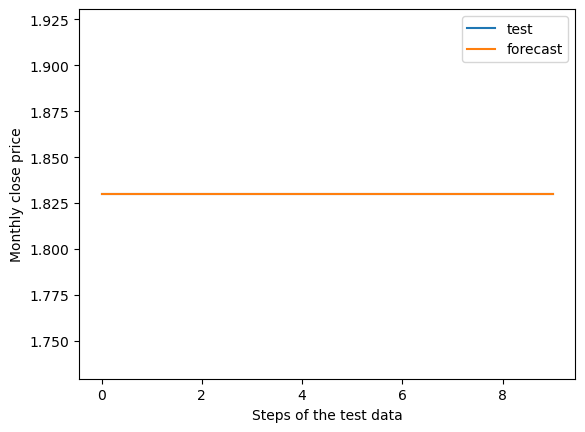

r2_score:  0.22499999999999998
rmse:  3.9094986940344543e-16
description:  count    115.000000
mean       1.804087
std        0.277729
min        1.090000
25%        1.500000
50%        1.830000
75%        1.895000
max        2.600000
Name: close_price, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=pharmdeko_end_month_df['close_price'][:-10]
y_test=pharmdeko_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,1,0), 
seasonal_order=(0,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', pharmdeko_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [14]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=pharmdeko_end_month_df['returns'].dropna()[:-10]
test=pharmdeko_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, 1.0]
[0, 0, 0, 0, 0, 1, 0.0]
[0, 0, 0, 0, 0, 2, 0.0]
[0, 0, 0, 0, 1, 0, 1.0]
[0, 0, 0, 0, 1, 1, 0.0]
[0, 0, 0, 0, 1, 2, 0.0]
[0, 0, 0, 0, 2, 0, 0.0]
[0, 0, 0, 0, 2, 1, 0.0]
[0, 0, 0, 0, 2, 2, 0.0]
[0, 0, 0, 1, 0, 0, 0.0]
[0, 0, 0, 1, 0, 1, 0.0]
[0, 0, 0, 1, 0, 2, 0.0]
[0, 0, 0, 1, 1, 0, 0.0]
[0, 0, 0, 1, 1, 1, 0.0]
[0, 0, 0, 1, 1, 2, 0.0]
[0, 0, 0, 1, 2, 0, 0.0]
[0, 0, 0, 1, 2, 1, 0.0]
[0, 0, 0, 1, 2, 2, 0.0]
[0, 0, 0, 2, 0, 0, 0.0]
[0, 0, 0, 2, 0, 1, 0.0]
[0, 0, 0, 2, 0, 2, 0.0]
[0, 0, 0, 2, 1, 0, 0.0]
[0, 0, 0, 2, 1, 1, 0.0]
[0, 0, 0, 2, 1, 2, 0.0]
[0, 0, 0, 2, 2, 0, 0.0]
[0, 0, 0, 2, 2, 1, 0.0]
[0, 0, 0, 2, 2, 2, 0.0]
[0, 0, 1, 0, 0, 0, 0.0]
[0, 0, 1, 0, 0, 1, 0.0]
[0, 0, 1, 0, 0, 2, 0.0]
[0, 0, 1, 0, 1, 0, 0.0]
[0, 0, 1, 0, 1, 1, 0.0]
[0, 0, 1, 0, 1, 2, 0.0]
[0, 0, 1, 0, 2, 0, 0.0]
[0, 0, 1, 0, 2, 1, 0.0]
[0, 0, 1, 0, 2, 2, 0.0]
[0, 0, 1, 1, 0, 0, 0.0]
[0, 0, 1, 1, 0, 1, 0.0]
[0, 0, 1, 1, 0, 2, 0.0]
[0, 0, 1, 1, 1, 0, 0.0]
[0, 0, 1, 1, 1, 1, 0.0]
[0, 0, 1, 1, 1, 

In [15]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
364,1,1,1,1,1,1,0.0
479,1,2,2,2,0,2,0.0
480,1,2,2,2,1,0,0.0
481,1,2,2,2,1,1,0.0
482,1,2,2,2,1,2,0.0
...,...,...,...,...,...,...,...
486,2,0,0,0,0,0,1.0
243,1,0,0,0,0,0,1.0
162,0,2,0,0,0,0,1.0
720,2,2,2,2,0,0,1.0


Very unreliable.
